In [ ]:
# Step 1: Load the two datasets

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import re
from collections import OrderedDict
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/BI GROUP ASSIGNMENT/"

postings = pd.read_csv(base_path + "linkedin_job_postings.csv",
                        usecols=["job_link", "job_title"])
skills = pd.read_csv(base_path + "job_skills.csv",
                      usecols=["job_link", "job_skills"])

print("Postings loaded:", postings.shape)
print("Skills loaded:", skills.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Postings loaded: (1348454, 2)
Skills loaded: (1296381, 2)


In [ ]:
# Step 2: Check the basic structure of each file (rows, columns, data types)

print("=== linkedin_job_postings.csv ===")
print("Rows:", postings.shape[0])
print("Columns:", postings.shape[1])
print(postings.dtypes)
print(postings.head())

print("\n=== job_skills.csv ===")
print("Rows:", skills.shape[0])
print("Columns:", skills.shape[1])
print(skills.dtypes)
print(skills.head())

=== linkedin_job_postings.csv ===
Rows: 1348454
Columns: 2
job_link     object
job_title    object
dtype: object
                                            job_link  \
0  https://www.linkedin.com/jobs/view/account-exe...   
1  https://www.linkedin.com/jobs/view/registered-...   
2  https://www.linkedin.com/jobs/view/restaurant-...   
3  https://www.linkedin.com/jobs/view/independent...   
4  https://www.linkedin.com/jobs/view/group-unit-...   

                                           job_title  
0  Account Executive - Dispensing (NorCal/Norther...  
1                 Registered Nurse - RN Care Manager  
2               RESTAURANT SUPERVISOR - THE FORKLIFT  
3                      Independent Real Estate Agent  
4  Group/Unit Supervisor (Systems Support Manager...  

=== job_skills.csv ===
Rows: 1296381
Columns: 2
job_link      object
job_skills    object
dtype: object
                                            job_link  \
0  https://www.linkedin.com/jobs/view/housekeeper...   
1  

In [ ]:
# Step 3: Check for missing data

print("=== Missing values ===")
print("\nlinkedin_job_postings.csv:")
print(postings.isna().sum())
print(f"job_title missing %: {postings['job_title'].isna().mean()*100:.3f}%")

print("\njob_skills.csv:")
print(skills.isna().sum())
print(f"job_skills missing %: {skills['job_skills'].isna().mean()*100:.3f}%")

=== Missing values ===

linkedin_job_postings.csv:
job_link     0
job_title    0
dtype: int64
job_title missing %: 0.000%

job_skills.csv:
job_link         0
job_skills    2085
dtype: int64
job_skills missing %: 0.161%


In [ ]:
# Step 4: Check that job_link is unique (needed for joining the files)

print("=== job_link uniqueness ===")
print("Postings — total rows:", len(postings), "| unique job_link:", postings["job_link"].nunique())
print("Skills   — total rows:", len(skills), "| unique job_link:", skills["job_link"].nunique())

=== job_link uniqueness ===
Postings — total rows: 1348454 | unique job_link: 1348454
Skills   — total rows: 1296381 | unique job_link: 1296381


**Interpretation:**
 The number of unique job_link values matches the total row count in both files, confirming there are no duplicate postings. This means it's safe to use job_link as the join key without inflating any counts.

In [ ]:
# Step 5: Filter all job postings that mention "Analyst"

postings["title_clean"] = postings["job_title"].fillna("").str.strip().str.lower()

analysts = postings[
    postings["title_clean"].str.contains(r"\banalysts?\b", regex=True, na=False)
].copy()

print(f"Analyst jobs: {len(analysts):,}")
print(f"Unique Analyst titles: {analysts['title_clean'].nunique():,}")

Analyst jobs: 35,825
Unique Analyst titles: 18,514


**Interpretation:**
35,825 postings mention "Analyst" as a complete word, spread across 18,514 different titles. This is the starting population every family in RQ2 will be drawn from.


In [ ]:
# Step 6: Sort each posting into an analyst family (e.g. Business Analyst, Data Analyst)

FAMILY_PATTERNS = OrderedDict({
    "Business Analyst": r"\bbusiness\s+analysts?\b",
    "Business Intelligence Analyst": r"\bbusiness\s+intelligence\s+analysts?\b|\bbi\s+analysts?\b",
    "Data Analyst": r"\bdata\s+analysts?\b|\banalytics\s+analysts?\b",
    "Finance Analyst": r"\bfinancial\s+analysts?\b|\bfinance\s+analysts?\b|\bfp&a\s+analysts?\b|\bbudget\s+analysts?\b|\btreasury\s+analysts?\b|\btax\s+analysts?\b",
    "Systems Analyst": r"\bsystems?\s+analysts?\b|\bbusiness\s+systems?\s+analysts?\b|\bcomputer\s+systems?\s+analysts?\b",
    "Security Analyst": r"\binformation\s+security\s+analysts?\b|\bcyber\s*security\s+analysts?\b|\bcybersecurity\s+analysts?\b|\bsecurity\s+analysts?\b",
    "Operations Analyst": r"\boperations?\s+analysts?\b|\boperational\s+analysts?\b",
    "Program / Project Analyst": r"\bprogram\s+analysts?\b|\bproject\s+analysts?\b",
    "Intelligence Analyst": r"\bintelligence\s+analysts?\b",
    "Research Analyst": r"\bresearch\s+analysts?\b",
    "Risk / Fraud Analyst": r"\brisk\s+analysts?\b|\bfraud\s+analysts?\b",
    "Quality Analyst": r"\bquality\s+analysts?\b|\bqa\s+analysts?\b",
    "Supply Chain Analyst": r"\bsupply\s+chain\s+analysts?\b|\blogistics\s+analysts?\b",
    "Pricing Analyst": r"\bpricing\s+analysts?\b",
    "Marketing Analyst": r"\bmarketing\s+analysts?\b|\bmarket\s+analysts?\b",
    "Behavior Analyst (Excluded)": r"\bbehavio[u]?r\s+analysts?\b"
})

def classify_family(title):
    for family, pattern in FAMILY_PATTERNS.items():
        if re.search(pattern, str(title), flags=re.IGNORECASE):
            return family
    return "Other Analyst"

analysts["analyst_family"] = analysts["title_clean"].apply(classify_family)

print(analysts["analyst_family"].value_counts())

analyst_family
Other Analyst                    16386
Business Analyst                  4567
Finance Analyst                   3995
Data Analyst                      1943
Systems Analyst                   1918
Program / Project Analyst         1317
Operations Analyst                 901
Security Analyst                   894
Intelligence Analyst               709
Behavior Analyst (Excluded)        698
Research Analyst                   608
Risk / Fraud Analyst               444
Quality Analyst                    364
Business Intelligence Analyst      323
Pricing Analyst                    316
Supply Chain Analyst               298
Marketing Analyst                  144
Name: count, dtype: int64


**Note on the code:** These analyst-family classification rules are the group's agreed standard, taken from the group's shared **analyst_RQ_streamlined** notebook, and applied here so my results stay consistent with the rest of the group's work.

**Interpretation:** Business Analyst is the largest named family (4,567), while "Other Analyst" is the largest group overall (16,386, or 45.7%) — meaning almost half of all analyst postings don't match any named family. This matches the group's earlier finding and confirms the classification rule is working consistently.

In [ ]:
# Step 7: Check how much usable skill data each family has

comparison = analysts[["job_link", "analyst_family"]].merge(
    skills, on="job_link", how="left"
)

coverage = (
    comparison
    .assign(has_skills=comparison["job_skills"].notna())
    .groupby("analyst_family")
    .agg(
        Jobs=("job_link", "nunique"),
        Jobs_with_skills=("has_skills", "sum")
    )
)

coverage["Skill_coverage_pct"] = (
    coverage["Jobs_with_skills"] / coverage["Jobs"] * 100
).round(2)

print(coverage.sort_values("Jobs", ascending=False))

                                Jobs  Jobs_with_skills  Skill_coverage_pct
analyst_family                                                            
Other Analyst                  16386             15728               95.98
Business Analyst                4567              4431               97.02
Finance Analyst                 3995              3914               97.97
Data Analyst                    1943              1900               97.79
Systems Analyst                 1918              1881               98.07
Program / Project Analyst       1317              1180               89.60
Operations Analyst               901               838               93.01
Security Analyst                 894               861               96.31
Intelligence Analyst             709               669               94.36
Behavior Analyst (Excluded)      698               674               96.56
Research Analyst                 608               557               91.61
Risk / Fraud Analyst     

**Interpretation:**  Coverage ranges from 89.60% (Program/Project Analyst) to 99.45% (Quality Analyst). This spread shows that not every family's skill comparison will be equally reliable — some families have noticeably less usable data than others.


In [ ]:
# Step 7b: Check whether missing job_skills data is randomly distributed
# across analyst families, or concentrated in specific ones

missing_by_family = (
    comparison
    .assign(missing=comparison["job_skills"].isna())
    .groupby("analyst_family")["missing"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

print(missing_by_family)

analyst_family
Program / Project Analyst        10.40
Research Analyst                  8.39
Supply Chain Analyst              8.05
Operations Analyst                6.99
Intelligence Analyst              5.64
Marketing Analyst                 4.17
Other Analyst                     4.02
Security Analyst                  3.69
Behavior Analyst (Excluded)       3.44
Business Intelligence Analyst     3.41
Business Analyst                  2.98
Data Analyst                      2.21
Finance Analyst                   2.03
Systems Analyst                   1.93
Pricing Analyst                   1.90
Risk / Fraud Analyst              1.35
Quality Analyst                   0.55
Name: missing, dtype: float64


**Interpretation:** Missing skill data is not spread evenly across families — some families are missing far more than others. Program/Project Analyst has the highest missing rate (10.40%), while Quality Analyst has the lowest (0.55%), almost a 19x difference. This is also much higher than the 0.161% missing rate seen across the full j**ob_skills.csv dataset**, showing that analyst postings,especially Program/Project Analyst are more affected by missing skill data than the dataset as a whole. This confirms Program/Project Analyst and Supply Chain Analyst need a data-quality caveat when compared to Business Analyst in RQ2.

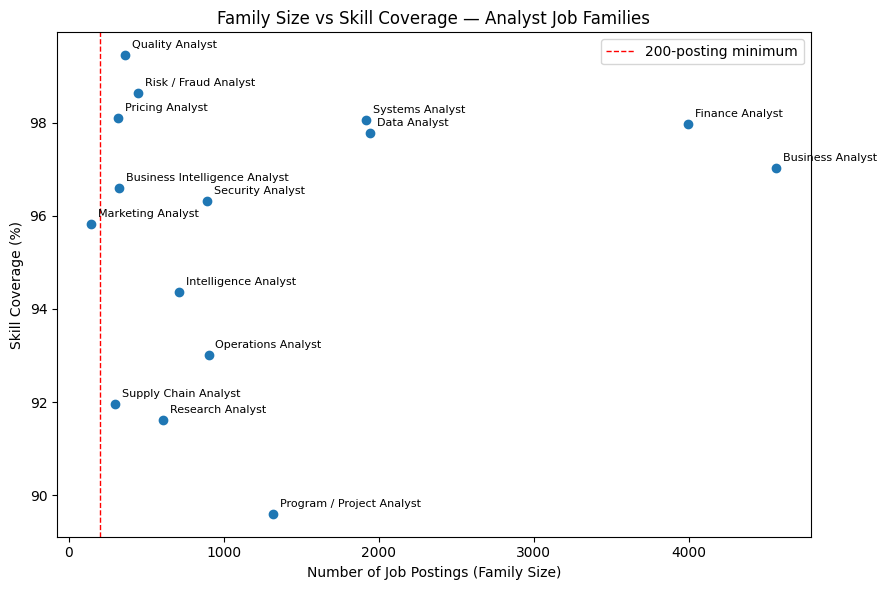

In [ ]:
# Step 8: Visualise family size against skill coverage

plot_data = coverage.drop(
    ["Other Analyst", "Behavior Analyst (Excluded)"],
    errors="ignore"
)

plt.figure(figsize=(9, 6))
plt.scatter(plot_data["Jobs"], plot_data["Skill_coverage_pct"])

for family, row in plot_data.iterrows():
    plt.annotate(family, (row["Jobs"], row["Skill_coverage_pct"]),
                 fontsize=8, xytext=(5, 5), textcoords="offset points")

plt.axvline(x=200, color="red", linestyle="--", linewidth=1, label="200-posting minimum")

plt.xlabel("Number of Job Postings (Family Size)")
plt.ylabel("Skill Coverage (%)")
plt.title("Family Size vs Skill Coverage — Analyst Job Families")
plt.legend()
plt.tight_layout()
plt.show()

**Interpretation:** There is no clear relationship between family size and skill coverage — several small families actually have high coverage. Two families stand out for different reasons: Supply Chain Analyst is small (298 postings) with low coverage (91.95%), and Program/Project Analyst has the lowest coverage overall (89.60%) despite being mid-sized (1,317 postings). Both will need a data-quality caveat when the RQ2 overlap comparison is run in October.

The 200-posting minimum shown above reflects our group's agreed preliminary threshold, below which Marketing Analyst (144 postings) was excluded from formal RQ2 comparison.

# **Result of Exploring the Data**
**What was done:** I loaded the two datasets, checked their basic structure and missing data, confirmed job_link was unique in both files, then filtered and classified all analyst postings into families using the group's agreed classification rules. I calculated each family's size and skill-data coverage, then plotted the two against each other.

**Why it was done:** This supports my RQ2 task, due 16 October. Before comparing skills across families, I needed to know whether small families are always the ones with weaker data, since that affects how much trust to place in each family's overlap score with Business Analyst.

**Result:** The data was clean — no missing job titles, only 0.161% missing skills, and no duplicate postings. Of 35,825 analyst postings, family sizes ranged from 4,567 (Business Analyst) down to 144 (Marketing Analyst), with almost half (45.7%) falling outside any named family.

Skill coverage ranged from 89.60% to 99.45%, and did not depend on family size — Supply Chain Analyst (298 postings, 91.95% coverage) and Program/Project Analyst (1,317 postings, 89.60% coverage) both stood out as risks, for different reasons.

Missing skill data was also concentrated rather than random — it ranged from a low of 0.55% (Quality Analyst) up to 10.40% (Program/Project Analyst), meaning Program/Project Analyst is the most affected family on both measures.

**What it means:** Family size alone cannot be used to judge how reliable a family's data is — each one needs to be checked individually.

**My contribution:** I used the group's agreed classification framework to test whether family size predicts data reliability, and identified two specific families, **Supply Chain Analyst and Program/Project Analyst**, that will need a data-quality caveat when I run the RQ2 comparison in October.